# Active Noise Cancellation — LMS and NLMS

This notebook applies the LMS algorithm to ANC without a reference signal (Hayes Fig. 9.14c), then introduces NLMS as a direct improvement.

1. LMS: ANC without a reference signal (Fig. 9.14c)
2. NLMS: Normalized LMS — side-by-side comparison

System identification and LMS background can be found in `ANC_LMS_SysID_Demo.ipynb`.

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. LMS for ANC — No Reference Signal (Hayes Fig. 9.14c)

In the feedforward model with no separate reference signal (Figure 9.14c), the single input $x[n]$ contains both the desired signal $d[n]$ and the noise $v_1[n]$:

$$x[n] = d[n] + v_1[n]$$

The algorithm delays $x[n]$ by $n_0$ samples and feeds that delayed signal into the adaptive filter:

$$\hat{d}[n] = \mathbf{w}_n^T \mathbf{x}_{n_0}[n]$$

where $\mathbf{x}_{n_0}[n] = [x[n-n_0],\, x[n-n_0-1],\, \ldots,\, x[n-n_0-M+1]]^T$.

The proof in Hayes (pp. 518–521) shows that if $n_0$ is large enough, the delayed signal is uncorrelated with the current $v_1[n]$ but still correlated with $d[n]$. The LMS algorithm then drives the filter to estimate $d[n]$, leaving:

$$e[n] = x[n] - \hat{d}[n] \approx \hat{v}_1[n]$$

The error output becomes the minimum mean-squared estimate of the noise $v_1[n]$.

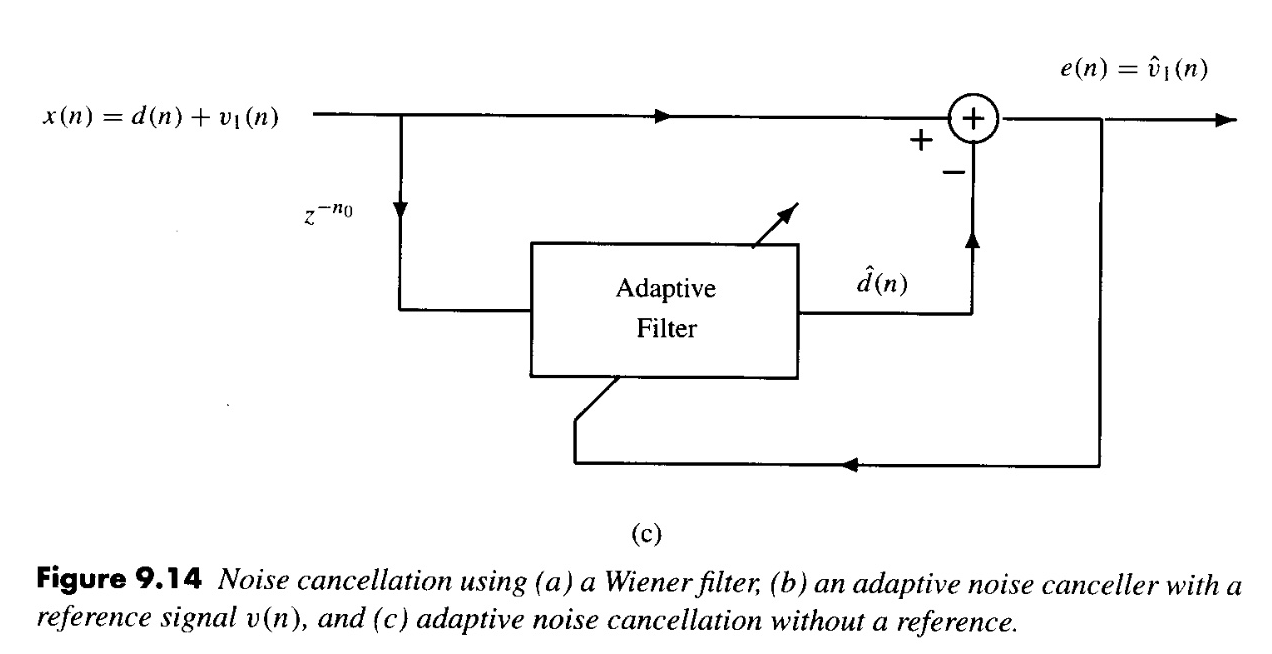
Reference:<br>
[1] Monson H. Hayes, *Statistical Digital Signal Processing and Modeling*. New York, NY, USA: John Wiley & Sons, 1996. (pp. 517)

The algorithm then takes the form:

For n = 0, 1, 2, ..., N-1: <br>
(a) $\widehat{d}[n]$ = **w**$_n^T$**x**$[n-n_0]$ <br>
(b) $e[n]$ = $x[n] - \widehat{d}[n]$ = $\widehat{v_1}[n]$ <br>
(c) **w**$_{n+1}$ = **w**$_n$ + $\mu e[n]$**x***$[n-n_0]$

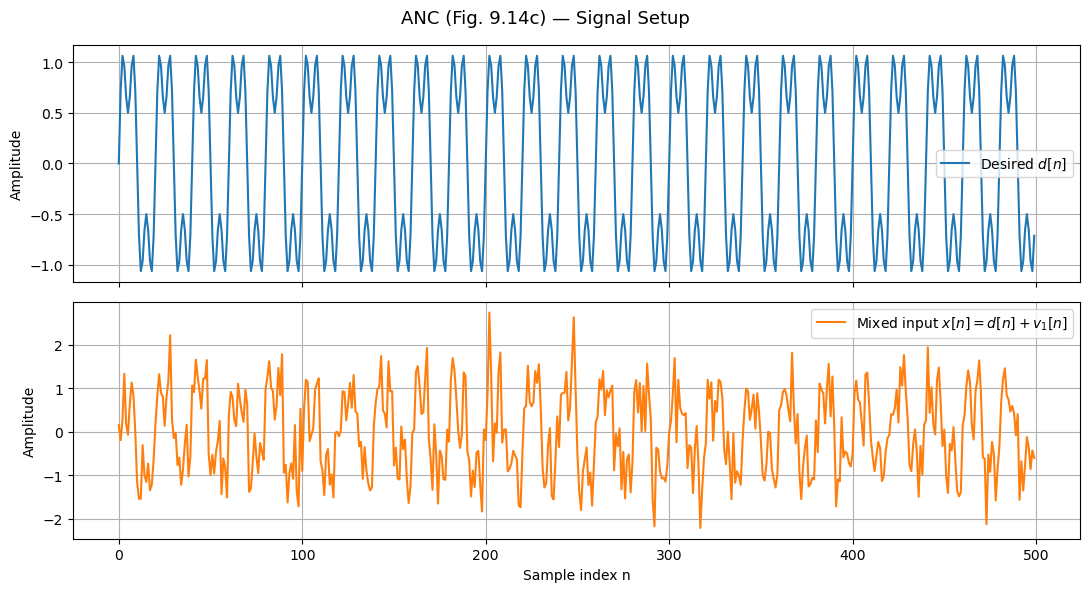

In [37]:
# Signal Setup
# x[n] = d[n] + v1[n]: single mixed input
# Output: d_hat[n]  (estimate of d[n])
# Error: e[n] = x[n] - d_hat[n]  ≈ v1_hat[n]
N = 500
n = np.arange(N)
n0 = 10  # delay (samples) — decorrelates v1[n] from filter input

# Desired signal d[n]: (correlated across n0 samples)
d = np.sin(2 * np.pi * 0.05 * n) + 0.5 * np.sin(2 * np.pi * 0.15 * n)

# Noise v1[n]: broadband white noise (decorrelates quickly)
v1 = 0.5 * np.random.randn(N)

# Mixed input: desired signal + noise
x = d + v1

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
fig.suptitle("ANC (Fig. 9.14c) — Signal Setup", fontsize=13)

axes[0].plot(n, d, label="Desired $d[n]$", lw=1.5, color="tab:blue")
axes[0].set_ylabel("Amplitude"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(n, x,  label="Mixed input $x[n] = d[n] + v_1[n]$", color="tab:orange")
axes[1].set_xlabel("Sample index n")
axes[1].set_ylabel("Amplitude"); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


LMS — noise reduction (steady state): -1.6 dB


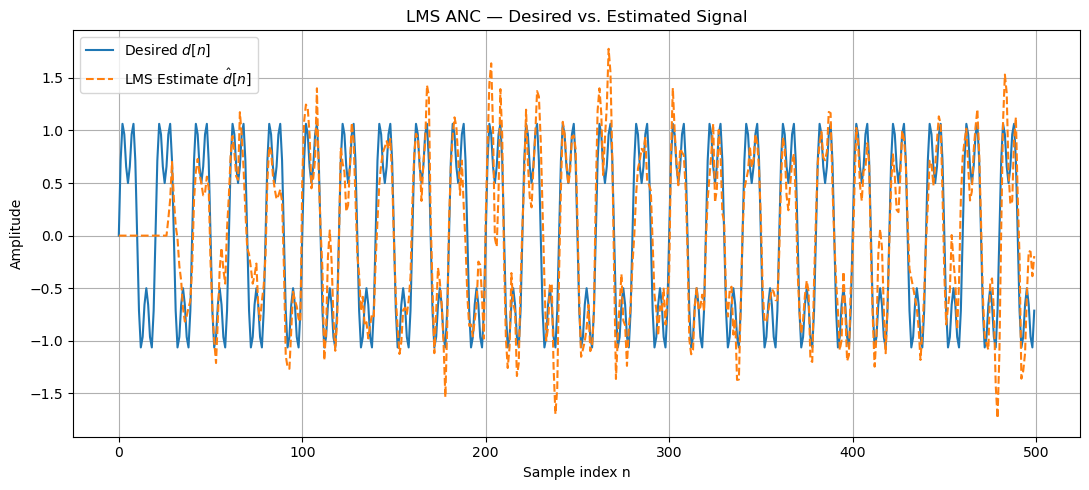

In [ ]:
# LMS — ANC without reference (Fig. 9.14c)

M = 16  # filter taps
mu = 0.02 # step size

d_hat_lms = np.zeros(N)
e_lms = np.zeros(N)
w_lms = np.zeros(M)

for i in range(n0 + M, N):
    # filter input: x delayed by n0, then M-tap window
    x_vec = x[i - n0 - M + 1 : i - n0 + 1][::-1]
    d_hat_lms[i] = np.dot(w_lms, x_vec)       
    e_lms[i] = x[i] - d_hat_lms[i]        
    w_lms = w_lms + mu * e_lms[i] * x_vec  

steady = N // 2  # approximate steady-state start after transient
snr_lms = 10 * np.log10(np.var(v1[steady:]) / (np.var(e_lms[steady:]) + 1e-12))
print(f"LMS — noise reduction (steady state): {snr_lms:.1f} dB")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(n, d, label="Desired $d[n]$", lw=1.5, color="tab:blue")
ax.plot(n, d_hat_lms, label="LMS Estimate $\hat{d}[n]$", color="tab:orange", linestyle="--")
ax.set_xlabel("Sample index n")
ax.set_ylabel("Amplitude")
ax.set_title("LMS ANC — Desired vs. Estimated Signal")
ax.legend(); ax.grid(True)

plt.tight_layout()
plt.show()


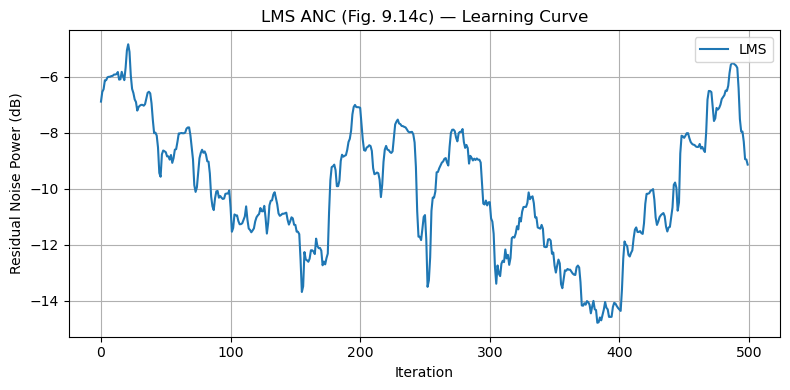

In [39]:
# Learning curve (LMS)
mse_lms = np.convolve((e_lms - v1)**2, np.ones(25) / 25, mode="same")

plt.figure(figsize=(8, 4))
plt.plot(10 * np.log10(mse_lms + 1e-12), label="LMS")
plt.title("LMS ANC (Fig. 9.14c) — Learning Curve")
plt.xlabel("Iteration")
plt.ylabel("Residual Noise Power (dB)")
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

# 2. NLMS — Normalized LMS

The Normalized LMS (NLMS) algorithm addresses a key sensitivity of LMS: the convergence rate and stability bound both depend on the input signal power $P_x = E[\|\mathbf{x}[n]\|^2]$. If the input level changes, a fixed $\mu$ can become too large (divergence) or too small (slow convergence).

NLMS normalizes the step size at each sample by the instantaneous input power:

$$\mathbf{w}_{n+1} = \mathbf{w}_n + \tilde{\mu},\frac{\mathbf{x}[n]}{\|\mathbf{x}[n]\|^2 + \epsilon}\, e[n]\$$


where $\tilde{\mu}$ is a normalized step size and $\epsilon > 0$ prevents division by zero. This makes the algorithm stable for $0 < \tilde{\mu} < 2$ regardless of input signal level, and typically converges faster than LMS for the same nominal step size.

Reference:<br>
[1] Monson H. Hayes, *Statistical Digital Signal Processing and Modeling*. New York, NY, USA: John Wiley & Sons, 1996. (pg. 514)

NLMS — noise reduction (steady state): -2.3 dB


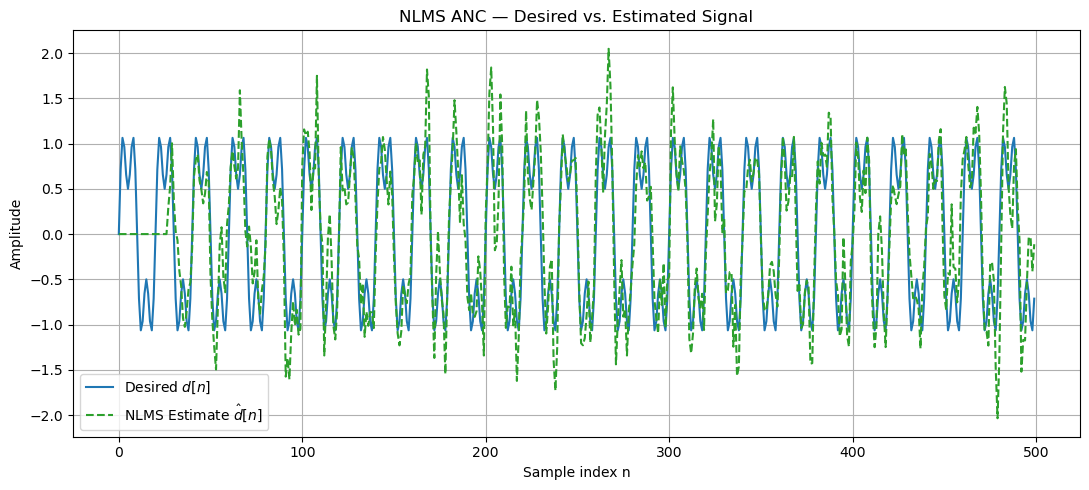

In [40]:
# NLMS — ANC without reference (same Fig. 9.14c setup)

mu_tilde = 0.5  # normalized step size  (stable for 0 < mu_tilde < 2)
eps = 1e-6  # regularization

d_hat_nlms = np.zeros(N)
e_nlms = np.zeros(N)
w_nlms = np.zeros(M)

for i in range(n0 + M, N):
    x_vec = x[i - n0 - M + 1 : i - n0 + 1][::-1]
    d_hat_nlms[i] = np.dot(w_nlms, x_vec)                             
    e_nlms[i] = x[i] - d_hat_nlms[i]                   
    mu_eff = mu_tilde / (np.dot(x_vec, x_vec) + eps) # normalized step
    w_nlms = w_nlms + mu_eff * e_nlms[i] * x_vec               # (c)

snr_nlms = 10 * np.log10 (np.var(v1[steady:]) / (np.var(e_nlms[steady:]) + 1e-12))
print(f"NLMS — noise reduction (steady state): {snr_nlms:.1f} dB")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(n, d, label="Desired $d[n]$", lw=1.5, color="tab:blue")
ax.plot(n, d_hat_nlms, label="NLMS Estimate $\hat{d}[n]$", color="tab:green", linestyle="--")
ax.set_xlabel("Sample index n")
ax.set_ylabel("Amplitude")
ax.set_title("NLMS ANC — Desired vs. Estimated Signal")
ax.legend(); ax.grid(True)

plt.tight_layout()
plt.show()


It can be seen from the plots below that NLMS is capable of faster convergence with a larger step size, made stable by the normalization. 

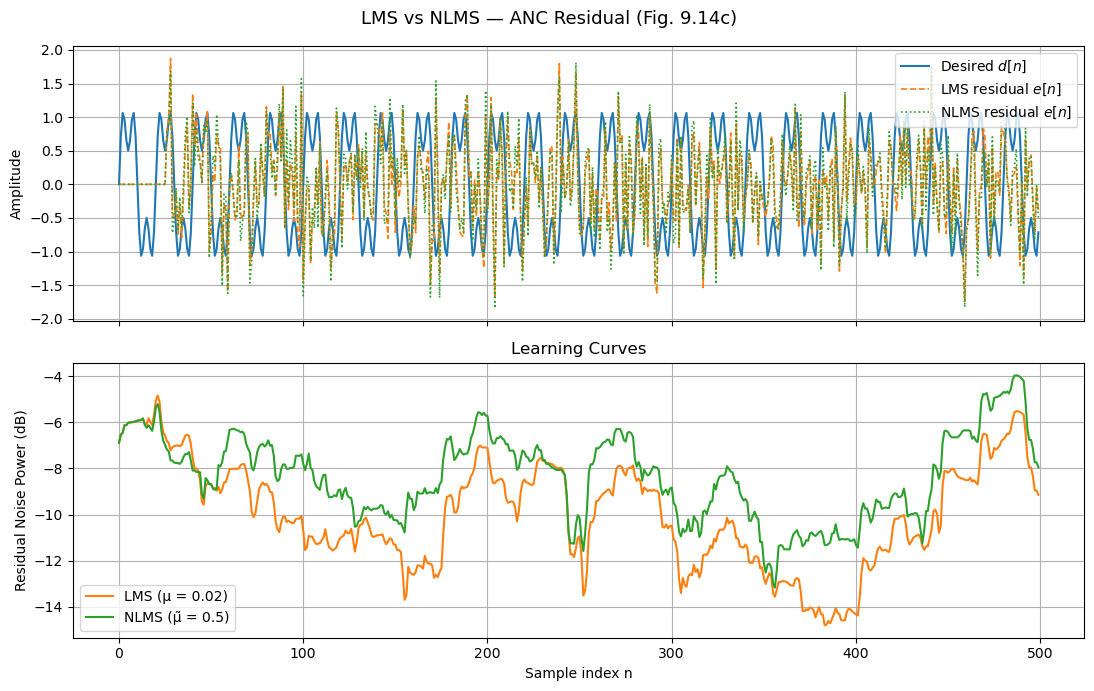


Steady-state noise reduction:
LMS: -1.6 dB
NLMS: -2.3 dB


In [41]:
# Side-by-side: LMS vs NLMS residual
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
fig.suptitle("LMS vs NLMS — ANC Residual (Fig. 9.14c)", fontsize=13)

axes[0].plot(n, d, label="Desired $d[n]$", lw=1.5, color="tab:blue")
axes[0].plot(n, e_lms, label="LMS residual $e[n]$",  lw=1.2, linestyle="--", color="tab:orange")
axes[0].plot(n, e_nlms, label="NLMS residual $e[n]$", lw=1.2, linestyle=":",  color="tab:green")
axes[0].set_ylabel("Amplitude"); axes[0].legend(); axes[0].grid(True)

# Learning curves
mse_nlms = np.convolve((e_nlms - v1)**2, np.ones(25) / 25, mode="same")

axes[1].plot(10 * np.log10(mse_lms + 1e-12), label=f"LMS (μ = {mu})", color="tab:orange")
axes[1].plot(10 * np.log10(mse_nlms + 1e-12), label=f"NLMS (μ̃ = {mu_tilde})", color="tab:green")
axes[1].set_xlabel("Sample index n")
axes[1].set_ylabel("Residual Noise Power (dB)")
axes[1].set_title("Learning Curves")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\nSteady-state noise reduction:")
print(f"LMS: {snr_lms:.1f} dB")
print(f"NLMS: {snr_nlms:.1f} dB")